In [1]:
print("hello")

hello


In [47]:
import  numpy as  np
import pandas as pd
import matplotlib.pyplot as plt 

In [3]:
x = np.array([1, 2, 3, 4])
y = np.array([2, 2.8, 3.6, 4.5])

In [41]:
w = 0 
b = 0
alpha = 0.001
num_iteration = 100

In [42]:
sse_value = []
for i in range(num_iteration):
    y_hat = w * x + b
    D_w = (2* np.sum((y_hat - y) * x ))
    D_b = (2 * np.sum((y_hat - y)))
    w = w - alpha * D_w
    b = b - alpha * D_b
    sse = (np.sum((y_hat - y) ** 2))
    sse_value.append(sse)
    if (i + 1) % 100 == 0:
        print(f"Iteration {i + 1}: w = {w}, b = {b}, SSE = {sse}")


Iteration 100: w = 1.06356303646273, b = 0.45972765199585214, SSE = 0.32178178914689


In [43]:
y_new = w * 5 + b
y_new

np.float64(5.777542834309502)

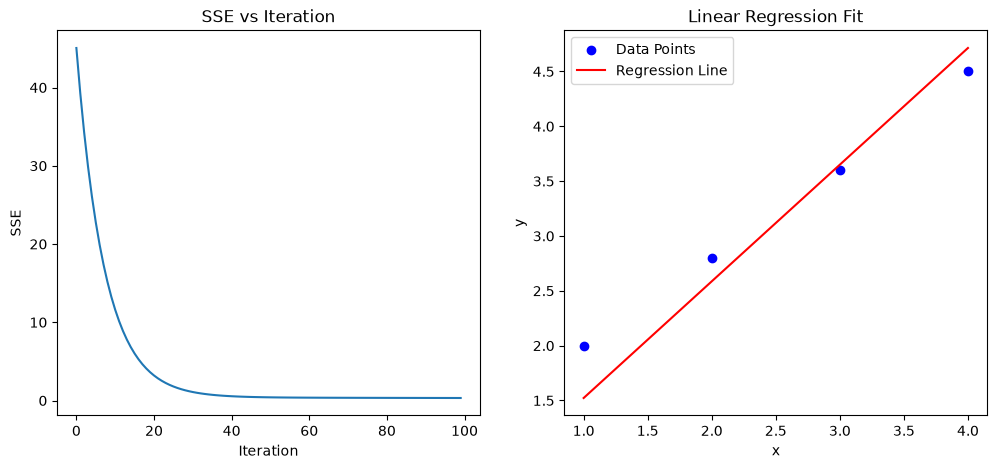

In [44]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(num_iteration), sse_value, label='SSE')
plt.xlabel('Iteration')
plt.ylabel('SSE')
plt.title('SSE vs Iteration')

plt.subplot(1, 2, 2)
plt.scatter(x, y, color='blue', label='Data Points')
plt.plot(x, y_hat, color='red', label='Regression Line')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Regression Fit')
plt.legend()
plt.show()

In [46]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x.reshape(-1, 1), y)
model.coef_, model.intercept_

(array([0.83]), np.float64(1.1500000000000004))

In [50]:
df = pd.read_csv("Salary_Data.csv")


In [51]:
df.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


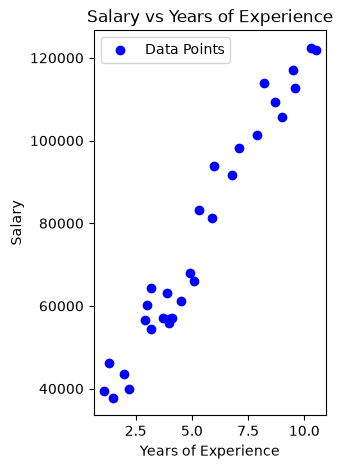

In [52]:
plt.figure(figsize=(3, 5))
plt.scatter(df['YearsExperience'], df['Salary'], color='blue', label='Data Points')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Salary vs Years of Experience')
plt.legend()
plt.show()

In [56]:
x = df.iloc[:,:-1].values
y = df.iloc[:,1].values

In [57]:
x

array([[ 1.1],
       [ 1.3],
       [ 1.5],
       [ 2. ],
       [ 2.2],
       [ 2.9],
       [ 3. ],
       [ 3.2],
       [ 3.2],
       [ 3.7],
       [ 3.9],
       [ 4. ],
       [ 4. ],
       [ 4.1],
       [ 4.5],
       [ 4.9],
       [ 5.1],
       [ 5.3],
       [ 5.9],
       [ 6. ],
       [ 6.8],
       [ 7.1],
       [ 7.9],
       [ 8.2],
       [ 8.7],
       [ 9. ],
       [ 9.5],
       [ 9.6],
       [10.3],
       [10.5]])

In [58]:
y

array([ 39343,  46205,  37731,  43525,  39891,  56642,  60150,  54445,
        64445,  57189,  63218,  55794,  56957,  57081,  61111,  67938,
        66029,  83088,  81363,  93940,  91738,  98273, 101302, 113812,
       109431, 105582, 116969, 112635, 122391, 121872])

In [60]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, shuffle=True, random_state=0)
x_train.shape, x_test.shape, y_train.shape, y_test.shape


((24, 1), (6, 1), (24,), (6,))

In [61]:
linear_reg= LinearRegression()
linear_reg.fit(x_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[9312.58]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.678e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[12.65]


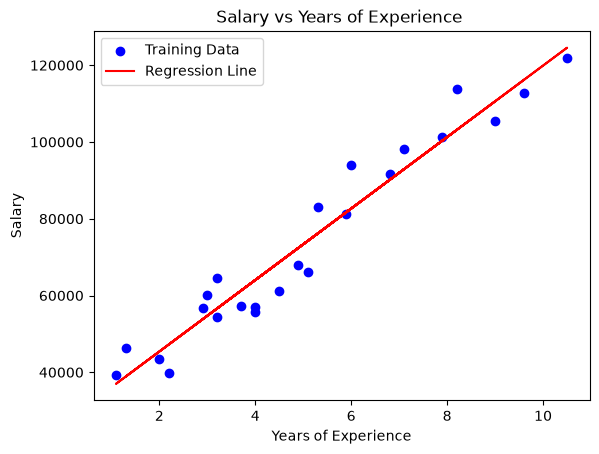

In [63]:
plt.scatter(x_train, y_train, color='blue', label='Training Data')
plt.plot(x_train, linear_reg.predict(x_train), color='red', label='Regression Line')
plt.title('Salary vs Years of Experience ')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.show()

In [66]:
from sklearn.metrics import mean_squared_error,r2_score
y_pred = linear_reg.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
root_mse = np.sqrt(mse)
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")
print(f"Root Mean Squared Error: {root_mse}")


Mean Squared Error: 12823412.298126549
R-squared: 0.988169515729126
Root Mean Squared Error: 3580.979237321343


In [74]:
b,w = linear_reg.intercept_, linear_reg.coef_
print(f"Intercept (b): {b}")
print(f"Coefficient (w): {w[0]}")

Intercept (b): 26780.09915062818
Coefficient (w): 9312.575126729189


In [72]:
y_h =9312.5 * 1.1 +26780.09
y_h

37023.84